In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Data Preparation for Country Revenue Analysis

In [75]:
df = pd.read_csv('../data/processed/cleaned_sales_data.csv', parse_dates=['InvoiceDate'])
df['Country'] =  df['Country'].str.title().str.strip()
df = df[df['Country'] != 'Unspecified']

## Calculating Country Revenue

In [76]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
top_countries_by_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

uk_total_revenue_percent = (top_countries_by_revenue['United Kingdom'] / df['Revenue'].sum()) * 100 # 81.56% of total revenue

## Graph (Bar) With UK

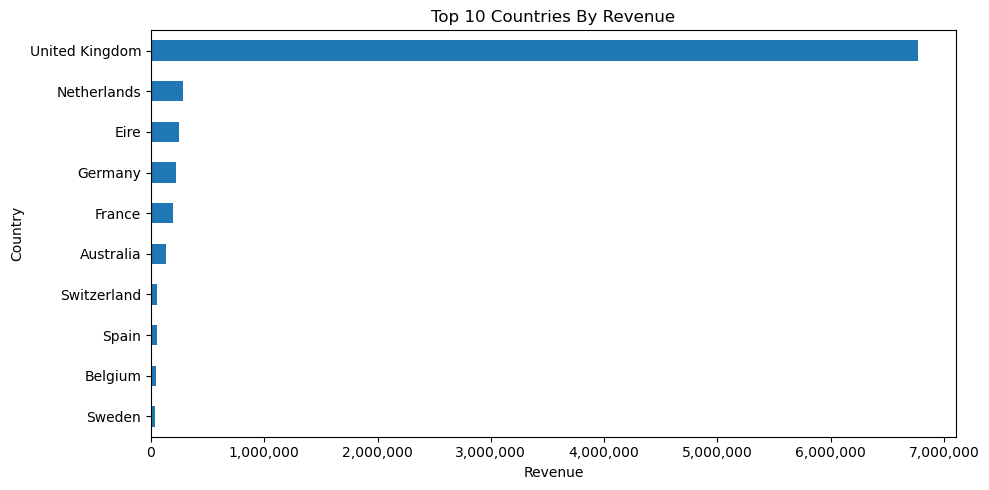

In [82]:
x_format = top_countries_by_revenue.sort_values().plot(kind='barh', figsize=(10,5))
x_format.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Top 10 Countries By Revenue')
plt.xlabel('Revenue')
plt.tight_layout()
plt.savefig('../outputs/graphs/countries_revenue_including_uk')
plt.show()

### INSIGHT 
United Kingdom is dominating with **81.56%** of total revenue.

These are not because of large purchases, but by a large customer/order base.

Business is strongly UK oriented.

## Graph (Bar) Without UK

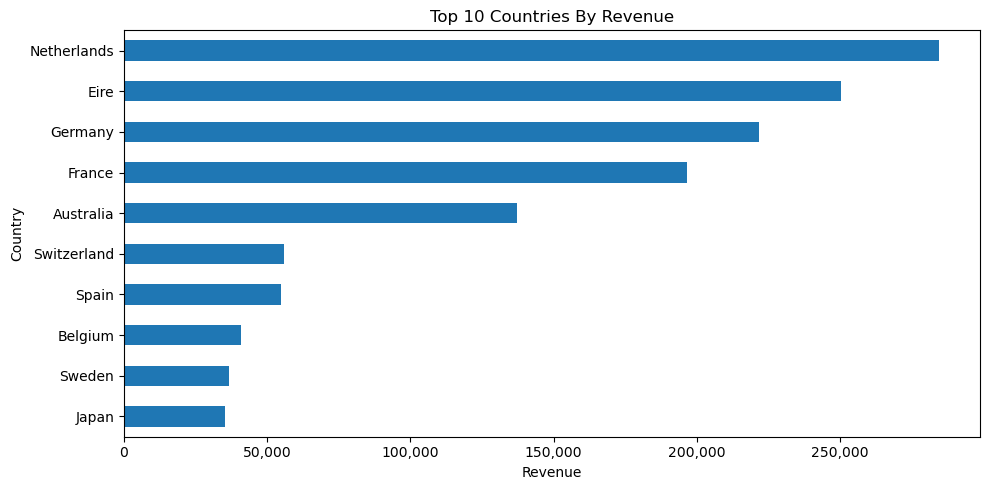

In [81]:
df_filter_without_uk = df[df['Country'] != 'United Kingdom']
df_without_uk = df_filter_without_uk.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
df_without_uk

x_format = df_without_uk.sort_values().plot(kind='barh', figsize=(10,5))
x_format.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Top 10 Countries By Revenue')
plt.xlabel('Revenue')
plt.tight_layout()
plt.savefig('../outputs/graphs/countries_revenue_without_uk')
plt.show()

### INSIGHT
Outside the UK, revenue is distributed more evenly across group of markets, with the Netherlands, Eire, Germany, France and Australia leading international sales.

## Storing first 10 countries to reports WITH UNITED KINGDOM

In [79]:
top_countries_by_revenue.to_csv('../outputs/reports/countries_revenue.csv')

## Storing first 10 countries to reports WITHOUT UNITED KINGDOM

In [80]:
df_without_uk.to_csv('../outputs/reports/countries_without_uk_revenue.csv')